# Minnesota Housing Price Prediction
## End-to-End Machine Learning Project
Based on Chapter 2 of *Hands-On Machine Learning* (Géron, 3rd Ed.)  
Dataset: `housing_data_minnesota.csv`

### Imports and Setup

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pandas.plotting import scatter_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rc('font', size=12)
plt.rc('axes', labelsize=12, titlesize=13)

figdir = Path('figures')
figdir.mkdir(exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(figdir / f'{name}.png', dpi=150)
    plt.show()
    plt.close()

---
## Task 1 - Exploratory Data Analysis

### Load the Dataset

In [ ]:
housing = pd.read_csv('housing_data_minnesota.csv')
print('Dataset shape:', housing.shape)
print(housing.head())
print()
housing.info()
print()
print(housing.describe())

Dataset shape: (500, 13)
   longitude   latitude  housing_median_age  total_rooms  total_bedrooms  \
0 -94.378587  47.688970                  51         2589             337   
1 -89.884428  46.716578                  16         1539            2528   
2 -91.590447  45.357166                  66         5670            2630   
3 -92.630464  48.382770                  12          425            2060   
4 -96.083055  47.608387                  25         4365            1148   

   population  households  median_income  median_house_value  \
0        7133        1332   36827.306919       451800.295900   
1        1097        3539   33440.556149       523564.401459   
2        3562        3511   83349.332844       433517.254186   
3        2836        3572   95864.754386       421460.152376   
4       13380        1187   92561.226795       470184.521490   

   school_quality_index  distance_to_highway  property_tax_rate  \
0              2.702252             1.738713           1.228821   

In [ ]:
# see what categories we have
print('Climate zones:')
print(housing['climate_zone'].value_counts())

Climate zones:
climate_zone
Cold Continental     252
Humid Continental    248
Name: count, dtype: int64


### Histograms

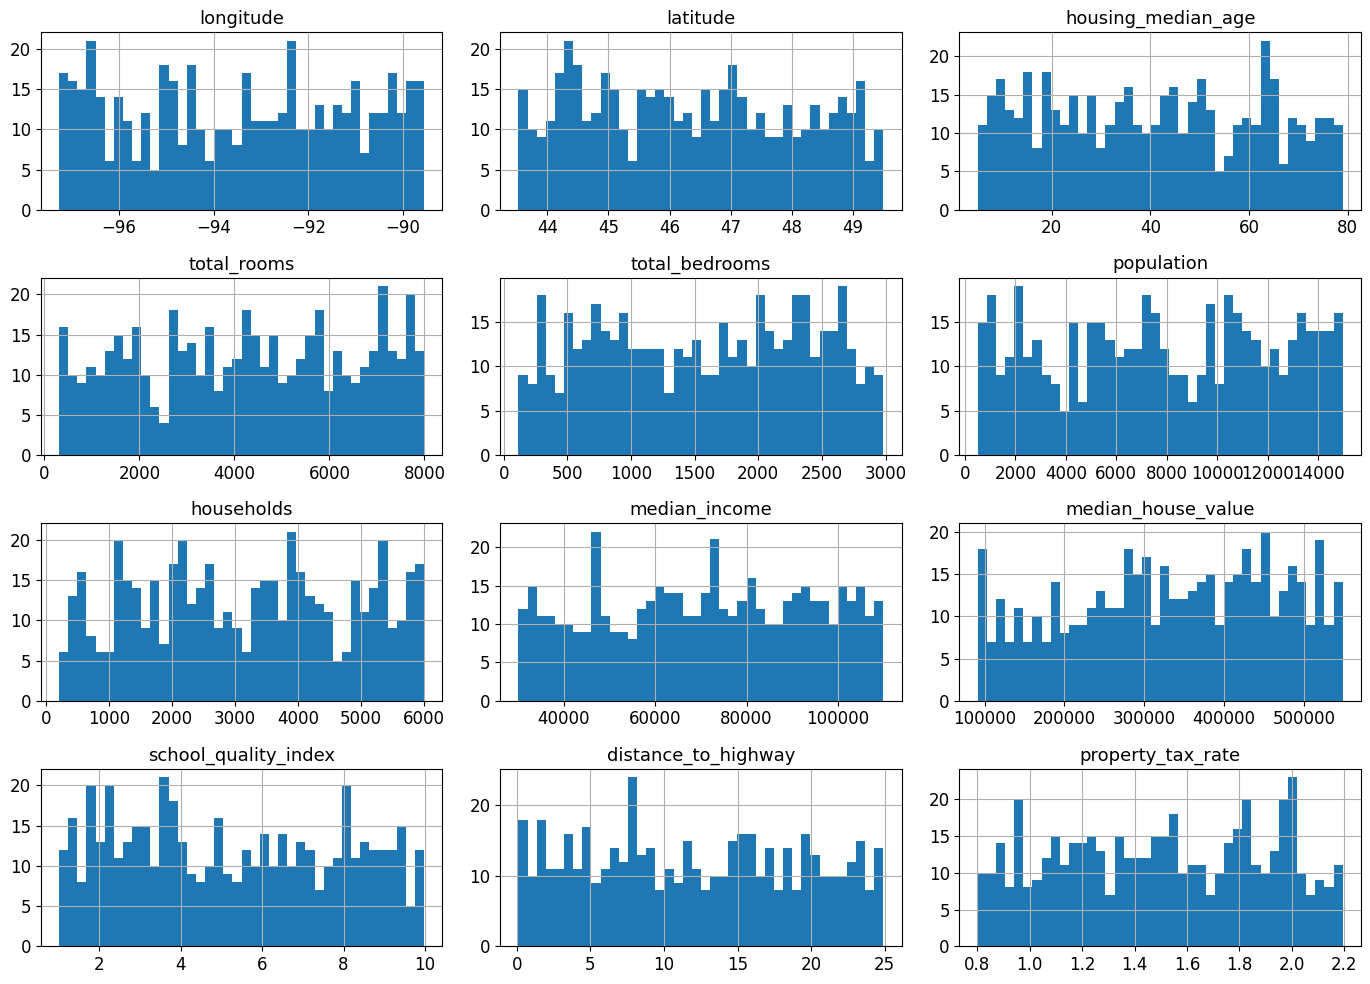

In [ ]:
housing.hist(bins=40, figsize=(14, 10))
savefig('01_histograms')

### Geographic Scatter Plot

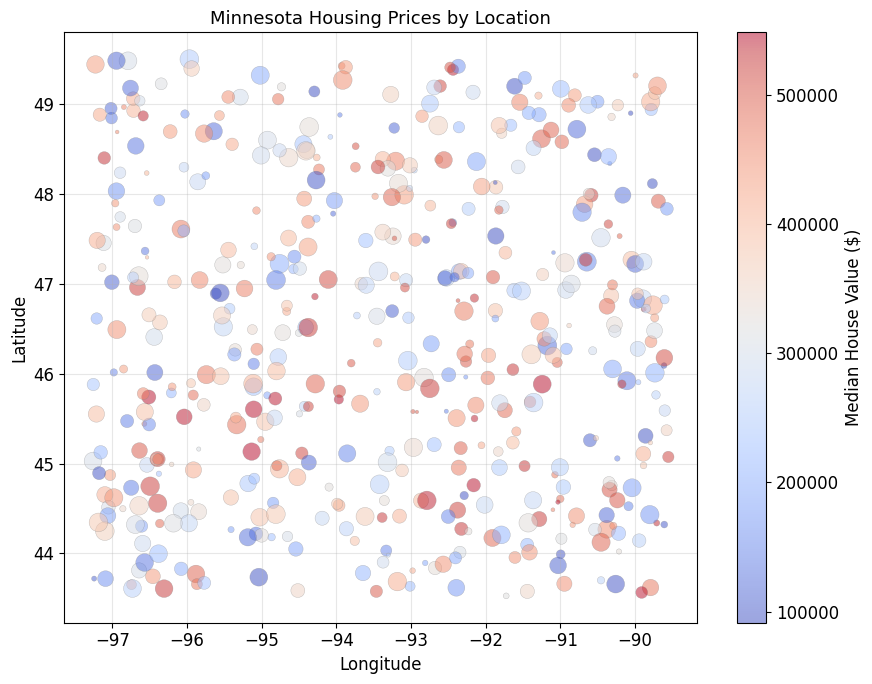

In [ ]:
fig, ax = plt.subplots(figsize=(9,7))
sc = ax.scatter(housing['longitude'], housing['latitude'],
                c=housing['median_house_value'], cmap='coolwarm',
                s=housing['population']/80, alpha=0.5,
                edgecolors='grey', linewidth=0.3)
plt.colorbar(sc, ax=ax, label='Median House Value ($)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Minnesota Housing Prices by Location')
ax.grid(alpha=0.3)
savefig('02_geo_scatter')

### Correlation Matrix

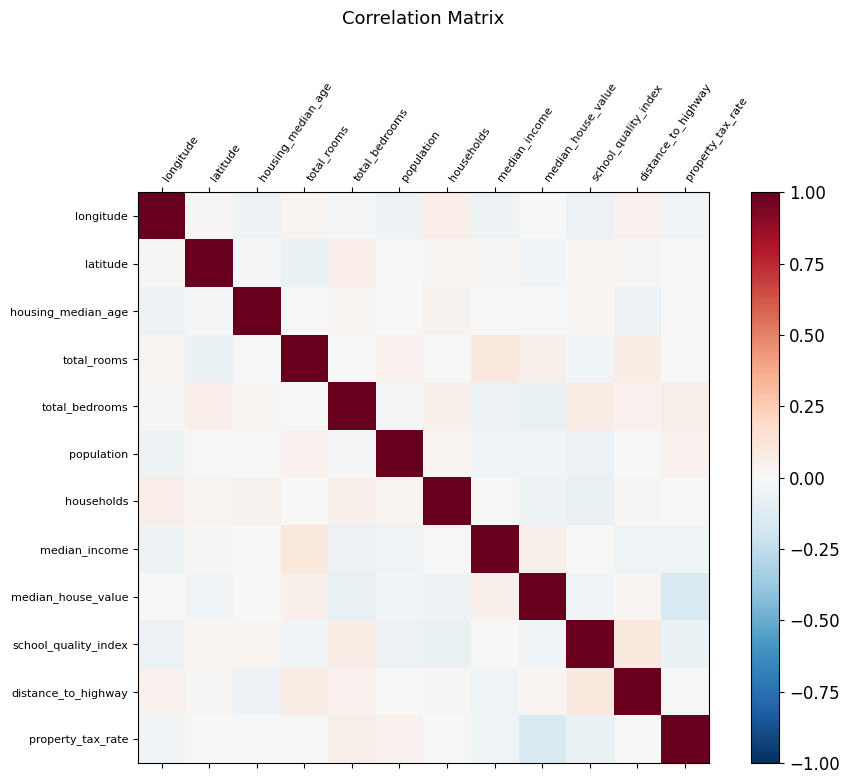

Correlations with median_house_value:
median_house_value      1.000000
median_income           0.049586
total_rooms             0.048000
distance_to_highway     0.016879
longitude               0.007446
housing_median_age      0.003869
population             -0.024455
school_quality_index   -0.027048
latitude               -0.029889
households             -0.048796
total_bedrooms         -0.077675
property_tax_rate      -0.148734
Name: median_house_value, dtype: float64


In [ ]:
corr_matrix = housing.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.matshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im)
cols = corr_matrix.columns.tolist()
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=55, ha='left', fontsize=8)
ax.set_yticklabels(cols, fontsize=8)
ax.set_title('Correlation Matrix', pad=40)
savefig('03_corr_matrix')

print('Correlations with median_house_value:')
print(corr_matrix['median_house_value'].sort_values(ascending=False))

### Scatter Matrix and Income vs Value

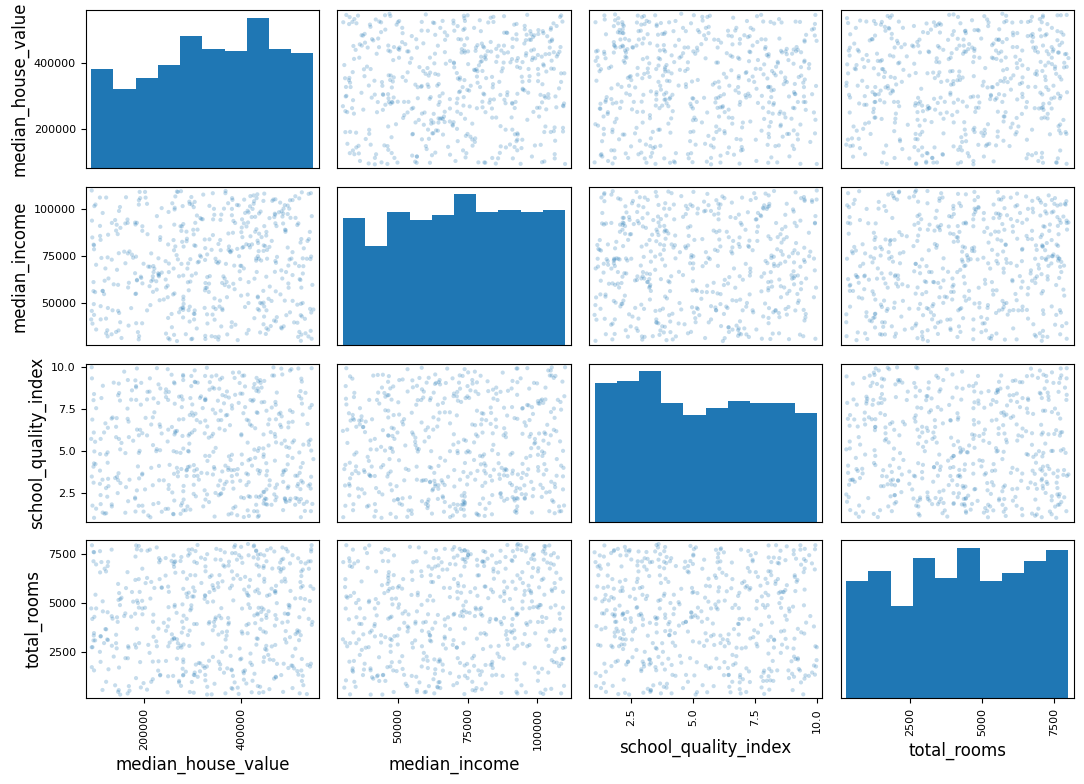

In [ ]:
pick = ['median_house_value', 'median_income', 'school_quality_index', 'total_rooms']
scatter_matrix(housing[pick], figsize=(11, 8), alpha=0.25)
savefig('04_scatter_matrix')

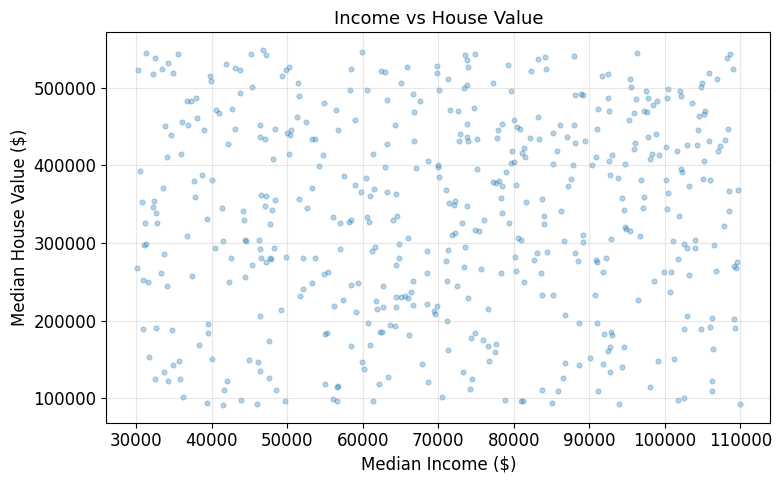

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(housing['median_income'], housing['median_house_value'], alpha=0.3, s=12)
ax.set_xlabel('Median Income ($)')
ax.set_ylabel('Median House Value ($)')
ax.set_title('Income vs House Value')
ax.grid(alpha=0.3)
savefig('05_income_vs_value')

### Income Stratification for Sampling

Income distribution:
count       500.000000
mean      70964.455724
std       22887.856984
min       30035.422515
25%       51368.661721
50%       71931.837452
75%       91011.140341
max      109963.513498
Name: median_income, dtype: float64


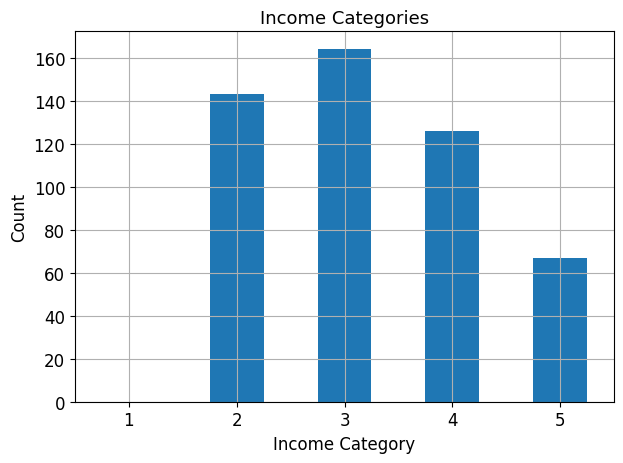

In [ ]:
# looked at describe() output to pick reasonable bin edges
print('Income distribution:')
print(housing['median_income'].describe())

housing['income_cat'] = pd.cut(housing['median_income'],
                               bins=[0, 30000, 55000, 80000, 100000, np.inf],
                               labels=[1, 2, 3, 4, 5])

housing['income_cat'].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.title('Income Categories')
savefig('06_income_categories')

### Stratified Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2,
                                       stratify=housing['income_cat'],
                                       random_state=42)

# quick sanity check on proportions
def get_proportions(data):
    return data['income_cat'].value_counts() / len(data)

compare = pd.DataFrame({
    'Overall': get_proportions(housing),
    'Test Set': get_proportions(test_set),
}).sort_index()
compare['Error %'] = ((compare['Test Set'] / compare['Overall']) - 1) * 100
print('Stratification check:')
print(compare.round(3))

# remove the temp column
for s in (train_set, test_set):
    s.drop('income_cat', axis=1, inplace=True)

housing = train_set.copy()  # working copy

Stratification check:
            Overall  Test Set  Error %
income_cat                            
1             0.000      0.00      NaN
2             0.286      0.29    1.399
3             0.328      0.33    0.610
4             0.252      0.25   -0.794
5             0.134      0.13   -2.985


---
## Task 2 - Data Preparation

In [ ]:
X_train = train_set.drop('median_house_value', axis=1)
y_train = train_set['median_house_value'].copy()

print('Missing values check:')
print(X_train.isnull().sum())

Missing values check:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms          0
population              0
households              0
median_income           0
school_quality_index    0
distance_to_highway     0
property_tax_rate       0
climate_zone            0
dtype: int64


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.base import BaseEstimator, TransformerMixin


# custom transformer to add derived features
class AddDerivedFeatures(BaseEstimator, TransformerMixin):
    """rooms_per_household, bedrooms_per_room, population_per_household"""
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df = X.copy()
        df['rooms_per_household'] = df['total_rooms'] / df['households']
        df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
        df['population_per_household'] = df['population'] / df['households']
        return df

In [ ]:
# test the transformer real quick
tmp = AddDerivedFeatures().fit_transform(X_train)
print('Correlations with new features (vs median_income):')
print(tmp.corr(numeric_only=True)['median_income'].sort_values(ascending=False).head(8))

Correlations with new features (vs median_income):
median_income               1.000000
total_rooms                 0.135861
rooms_per_household         0.117448
school_quality_index        0.057303
population_per_household    0.032105
latitude                    0.012322
housing_median_age         -0.012222
households                 -0.018343
Name: median_income, dtype: float64


### Build Preprocessing Pipeline

In [ ]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

col_transformer = ColumnTransformer([
    ('num', num_pipeline, make_column_selector(dtype_include=np.number)),
    ('cat', OneHotEncoder(handle_unknown='ignore'),
     make_column_selector(dtype_include=object)),
])

# full pipeline = feature engineering then column transformer
prep_pipeline = Pipeline([
    ('add_features', AddDerivedFeatures()),
    ('col_transform', col_transformer),
])

X_train_prepared = prep_pipeline.fit_transform(X_train)
print('Shape after preprocessing:', X_train_prepared.shape)

Shape after preprocessing: (400, 16)


---
## Task 3 - Model Training & Cross Validation

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score


# helper to build a fresh pipeline with any model plugged in
# need this because cross_val_score clones the estimator
def make_model_pipeline(model):
    npipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    ct = ColumnTransformer([
        ('num', npipe, make_column_selector(dtype_include=np.number)),
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         make_column_selector(dtype_include=object)),
    ])
    return Pipeline([
        ('add_features', AddDerivedFeatures()),
        ('col_transform', ct),
        ('model', model),
    ])


# quick function to run CV and print results
def run_cv(label, mdl, X, y, k=5):
    scores = -cross_val_score(mdl, X, y,
                              scoring='neg_root_mean_squared_error', cv=k)
    print(f'\n{label} ({k}-fold CV)')
    print(f'  Scores: {scores.round(0)}')
    print(f'  Mean RMSE: {scores.mean():.0f}  Std: {scores.std():.0f}')
    return scores

### Training RMSE (on training set)

In [ ]:
lr_pipe = make_model_pipeline(LinearRegression())
lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_train)
print(f'Linear Regression training RMSE: ${np.sqrt(mean_squared_error(y_train, lr_pred)):,.0f}')

dt_pipe = make_model_pipeline(DecisionTreeRegressor(random_state=42))
dt_pipe.fit(X_train, y_train)
dt_pred = dt_pipe.predict(X_train)
print(f'Decision Tree training RMSE: ${np.sqrt(mean_squared_error(y_train, dt_pred)):,.0f}')
# decision tree memorizes -> 0 rmse on training data

rf_pipe = make_model_pipeline(RandomForestRegressor(n_estimators=100, random_state=42))
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_train)
print(f'Random Forest training RMSE: ${np.sqrt(mean_squared_error(y_train, rf_pred)):,.0f}')

Linear Regression training RMSE: $125,714
Decision Tree training RMSE: $0
Random Forest training RMSE: $49,991


### Cross-Validation

In [ ]:
lr_scores = run_cv('Linear Regression',
                   make_model_pipeline(LinearRegression()),
                   X_train, y_train)

dt_scores = run_cv('Decision Tree',
                   make_model_pipeline(DecisionTreeRegressor(random_state=42)),
                   X_train, y_train)

rf_scores = run_cv('Random Forest',
                   make_model_pipeline(RandomForestRegressor(n_estimators=100,
                                                             random_state=42)),
                   X_train, y_train)


Linear Regression (5-fold CV)
  Scores: [130815. 128789. 131322. 124306. 137417.]
  Mean RMSE: 130530  Std: 4240

Decision Tree (5-fold CV)
  Scores: [189256. 206082. 197037. 180981. 190640.]
  Mean RMSE: 192799  Std: 8382

Random Forest (5-fold CV)
  Scores: [132983. 135948. 132894. 128612. 138163.]
  Mean RMSE: 133720  Std: 3225


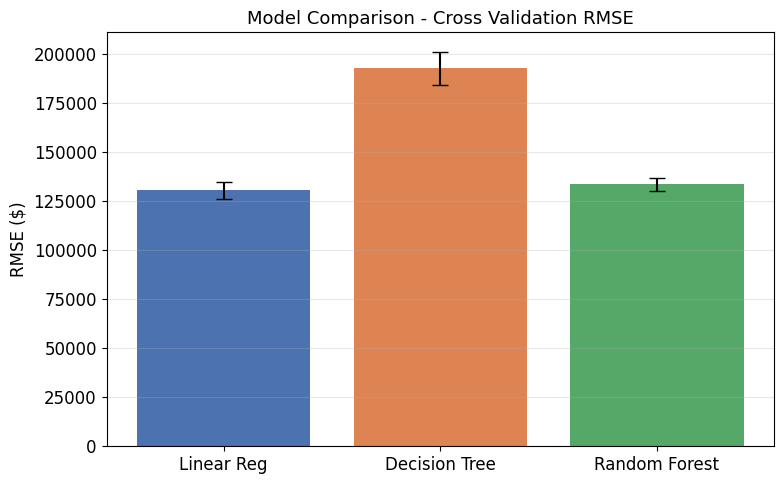

In [ ]:
# plot comparison
fig, ax = plt.subplots(figsize=(8, 5))
names = ['Linear Reg', 'Decision Tree', 'Random Forest']
means = [lr_scores.mean(), dt_scores.mean(), rf_scores.mean()]
stds = [lr_scores.std(), dt_scores.std(), rf_scores.std()]
bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=['#4c72b0', '#dd8452', '#55a868'])
ax.set_ylabel('RMSE ($)')
ax.set_title('Model Comparison - Cross Validation RMSE')
ax.grid(axis='y', alpha=0.3)
savefig('07_model_comparison')

### Hyperparameter Tuning - GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

gs_pipe = make_model_pipeline(RandomForestRegressor(random_state=42))

param_grid = [
    {'model__n_estimators': [30, 60, 100],
     'model__max_features': [4, 6, 8]},
    {'model__n_estimators': [30, 60],
     'model__max_features': [3, 5],
     'model__bootstrap': [False]},
]

grid_search = GridSearchCV(gs_pipe, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error',
                           return_train_score=True)
grid_search.fit(X_train, y_train)

print('--- Grid Search ---')
print('Best params:', grid_search.best_params_)
print(f'Best RMSE: ${-grid_search.best_score_:,.0f}')

cvr = grid_search.cv_results_
print('\nAll combos:')
for score, params in sorted(zip(cvr['mean_test_score'], cvr['params']), reverse=True):
    print(f'  ${-score:,.0f}  {params}')

--- Grid Search ---
Best params: {'model__max_features': 4, 'model__n_estimators': 100}
Best RMSE: $132,291

All combos:
  $132,291  {'model__max_features': 4, 'model__n_estimators': 100}
  $132,577  {'model__max_features': 6, 'model__n_estimators': 100}
  $132,816  {'model__max_features': 6, 'model__n_estimators': 60}
  $132,940  {'model__max_features': 8, 'model__n_estimators': 100}
  $133,154  {'model__max_features': 4, 'model__n_estimators': 60}
  $133,796  {'model__max_features': 6, 'model__n_estimators': 30}
  $134,210  {'model__max_features': 8, 'model__n_estimators': 60}
  $134,339  {'model__max_features': 8, 'model__n_estimators': 30}
  $135,339  {'model__bootstrap': False, 'model__max_features': 3, 'model__n_estimators': 60}
  $135,543  {'model__max_features': 4, 'model__n_estimators': 30}
  $136,519  {'model__bootstrap': False, 'model__max_features': 3, 'model__n_estimators': 30}
  $138,415  {'model__bootstrap': False, 'model__max_features': 5, 'model__n_estimators': 60}
  $

### Hyperparameter Tuning - RandomizedSearchCV

In [ ]:
rs_pipe = make_model_pipeline(RandomForestRegressor(random_state=42))

param_dist = {
    'model__n_estimators': randint(20, 200),
    'model__max_features': randint(2, 10),
}

rand_search = RandomizedSearchCV(rs_pipe, param_distributions=param_dist,
                                 n_iter=15, cv=3,
                                 scoring='neg_root_mean_squared_error',
                                 random_state=42)
rand_search.fit(X_train, y_train)

print('--- Randomized Search ---')
print('Best params:', rand_search.best_params_)
print(f'Best RMSE: ${-rand_search.best_score_:,.0f}')

--- Randomized Search ---
Best params: {'model__max_features': 2, 'model__n_estimators': 77}
Best RMSE: $130,870


---
## Task 4 - Model Evaluation

### Feature Importances

In [ ]:
final_model = rand_search.best_estimator_

# pull out feature importances from the random forest step
rf_step = final_model.named_steps['model']
importances = rf_step.feature_importances_

# get feature names from the preprocessing step
try:
    ct_step = final_model.named_steps['col_transform']
    feature_names = ct_step.get_feature_names_out()
except:
    feature_names = [f'feat_{i}' for i in range(len(importances))]

ranking = np.argsort(importances)[::-1]

print('Top 10 Feature Importances:')
for i, idx in enumerate(ranking[:10]):
    print(f'  {i+1:2d}. {feature_names[idx]:35s} {importances[idx]:.4f}')

Top 10 Feature Importances:
   1. num__longitude                      0.0857
   2. num__latitude                       0.0779
   3. num__population                     0.0746
   4. num__median_income                  0.0742
   5. num__population_per_household       0.0710
   6. num__property_tax_rate              0.0689
   7. num__total_bedrooms                 0.0689
   8. num__school_quality_index           0.0686
   9. num__rooms_per_household            0.0683
  10. num__housing_median_age             0.0678


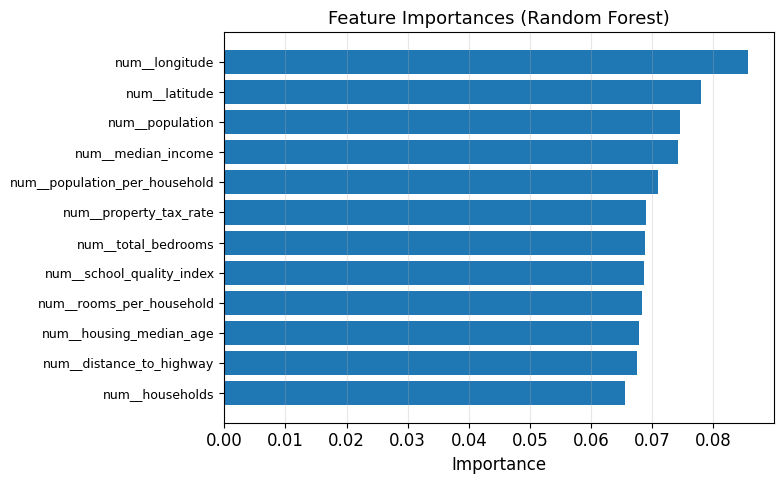

In [ ]:
# bar chart
n_show = min(12, len(importances))
top_idx = ranking[:n_show]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(n_show), importances[top_idx][::-1])
ax.set_yticks(range(n_show))
ax.set_yticklabels([feature_names[i] for i in top_idx][::-1], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Feature Importances (Random Forest)')
ax.grid(axis='x', alpha=0.3)
savefig('08_feature_importances')

### Test Set Evaluation

In [ ]:
X_test = test_set.drop('median_house_value', axis=1)
y_test = test_set['median_house_value'].copy()

preds = final_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f'Test Set RMSE: ${test_rmse:,.0f}')

# confidence interval
from scipy import stats

sq_errors = (preds - y_test) ** 2
ci = np.sqrt(stats.t.interval(0.95,
                               len(sq_errors) - 1,
                               loc=sq_errors.mean(),
                               scale=stats.sem(sq_errors)))
print(f'95% CI: [${ci[0]:,.0f}, ${ci[1]:,.0f}]')

Test Set RMSE: $138,811
95% CI: [$125,625, $150,849]


### Residual Plot

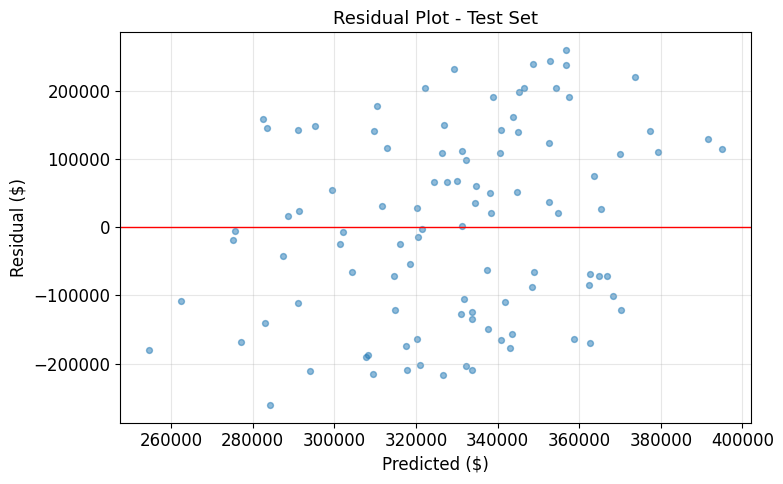

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
resids = preds - y_test
ax.scatter(preds, resids, alpha=0.5, s=18)
ax.axhline(0, color='red', lw=1)
ax.set_xlabel('Predicted ($)')
ax.set_ylabel('Residual ($)')
ax.set_title('Residual Plot - Test Set')
ax.grid(alpha=0.3)
savefig('09_residuals')

---
## Task 5 - Final Pipeline & Prediction

In [ ]:
# the final_model IS the full pipeline already
# (AddDerivedFeatures -> ColumnTransformer -> RandomForest)
# so we can just call .predict() on raw data

# trying it on a couple made up MN properties
new_data = pd.DataFrame({
    'longitude': [-93.27, -94.80],
    'latitude': [44.98, 46.50],
    'housing_median_age': [25, 40],
    'total_rooms': [5000, 3200],
    'total_bedrooms': [1100, 850],
    'population': [3500, 2100],
    'households': [1200, 700],
    'median_income': [72000, 48000],
    'school_quality_index': [7.5, 5.2],
    'distance_to_highway': [4.0, 15.0],
    'property_tax_rate': [1.35, 1.80],
    'climate_zone': ['Humid Continental', 'Cold Continental'],
})

new_preds = final_model.predict(new_data)
print('Predictions on new data:')
for i in range(len(new_data)):
    lat = new_data.iloc[i]['latitude']
    lon = new_data.iloc[i]['longitude']
    print(f'  Property {i+1} (lat={lat}, lon={lon}) -> ${new_preds[i]:,.0f}')

Predictions on new data:
  Property 1 (lat=44.98, lon=-93.27) -> $368,646
  Property 2 (lat=46.5, lon=-94.8) -> $365,968


---
### Project Complete
All 9 figures saved in the `figures/` folder.